# SeaBASS Data
all Concentration of chromophoric dissolved organic matter (CDOM) data on seabass was bulk downloaded from https://seabass.gsfc.nasa.gov/search#bio

The following boundries were used to gather CDOM and suspended data from seabass:
- dates: 2000-01-01 -> 2025-12-17
- lat: 74 to 17
- lon: -171 to -52
- products: a, DC, PC, SPM

get_files and get_folder_name are both used to gather all folders names in the requested files and to gather all .sb files within those folders

Please refer to the seabass_chl page for a deeper understanding on the seabass file structure. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [2]:
def get_files(dir):
    file_list = []
    for root, _, files in os.walk(dir): #here, dir would be the path to the requested_files
        for file in files:
            if file.endswith(".sb"):
                file_list.append(os.path.join(root, file))
    return file_list

def get_folder_names(folder_path):
  """
  Returns a list of folder names in the given directory.
  """
  folder_names = []
  for item in os.listdir(folder_path):
    item_path = os.path.join(folder_path, item)
    if os.path.isdir(item_path):
      folder_names.append(item)
  return folder_names


SeaBASS compiles raw data by including all variables recorded along with the ones asked for. This can result in sometimes thousands of column with variables we don't want. So subset the columns. 

In [3]:
selected_columns =['lat','lon','year','month','day','hour','minute','second','time','date','datetime' ,'ag', 'abs_ag', 'cdomf', 'cdmf', 'cdmf_rfu',
                   'pim', 'pic', 'spm', 'pom', 'turbidity', 'cdom','depth','station','wavelength'] #detect any column related to cdom

path_to_folder = r'C:\Users\gianna.milton\Documents\Python\CDOM\SB_products_all2\requested_files_5\requested_files'
all_folders = get_folder_names(path_to_folder)


The following three cells follow a very similar structure as to Seabass chlorophyll data; sb.files are turned into structured dataframes, all empty rows without the variables we want are removed, and lat, lon, and datetime are appended. 

In [4]:
for folders in range(len(all_folders)):
    #print(folders)
    f_list1 =  path_to_folder +'\\'+str(all_folders[folders])
    f_list = get_files(f_list1)
    print(str(all_folders[folders]))
    dfs = []  # list to collect all processed DataFrames
    for file in f_list:
        data1 = sb.readSB(filename=file, no_warn=True)
        data2 = data1.data
        df = pd.DataFrame.from_dict(data2, orient='index').T
        dt = None  # initialize datetime variable
        # Generate datetime column if possible
        if all(col in df.columns for col in ['year', 'month', 'day', 'hour', 'minute', 'second']):
            dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']])
        elif all(col in df.columns for col in ['year', 'month', 'day', 'hour', 'minute']):
            dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
        elif all(col in df.columns for col in ['year', 'month', 'day', 'time']):
            df['hour'] = df['time'].astype(str).str[:-6].astype(int)
            df['minute'] = df['time'].astype(str).str[-5:-3].astype(int)
            df['second'] = df['time'].astype(str).str[-2:].astype(int)
            dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']])
        elif all(col in df.columns for col in ['date', 'time']):
            df['year'] = df['date'].astype(str).str[:4].astype(int)
            df['month'] = df['date'].astype(str).str[4:6].astype(int)
            df['day'] = df['date'].astype(str).str[6:8].astype(int)
            time_strs = df['time'].astype(str) #some files have time as HH:mm, some as HH:mm:ss, so this accounts for both
            if time_strs.str.contains(":").all() and time_strs.str.count(":").eq(2).all():  #determine format based on string length or presence of ":"
                df['hour'] = time_strs.str.split(":").str[0].astype(int)
                df['minute'] = time_strs.str.split(":").str[1].astype(int)
                df['second'] = time_strs.str.split(":").str[2].astype(float).astype(int)
                dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']])
            elif time_strs.str.contains(":").all() and time_strs.str.count(":").eq(1).all():
                df['hour'] = time_strs.str.split(":").str[0].astype(int)
                df['minute'] = time_strs.str.split(":").str[1].astype(int)
                df['second'] = 0
                dt = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute', 'second']])
        else:
            dt = pd.NaT
        df.insert(0, 'datetime', dt) #insert datetime column into df
        columns_to_keep = [col for col in df.columns if col in selected_columns or col == 'datetime'] #only keep whatever columns are in selected_columns
        df_filtered = df[columns_to_keep]
        header = pd.DataFrame.from_dict(data1.headers, orient='index').T #create metedata header from dictionary and repeat it to match lenth of dataset
        header_repeated = pd.concat([header] * len(df_filtered), ignore_index=True)
        # Combine data and metadata
        combined = pd.concat([df_filtered.reset_index(drop=True), header_repeated], axis=1)
        combined = combined.loc[:, ~combined.columns.duplicated()]
        dfs.append(combined)
    #final concatenation
    globals()[str(all_folders[folders])] = pd.concat(dfs, ignore_index=True)

BIGELOW


NameError: name 'sb' is not defined

In [ ]:
cdom_columns =['ag', 'abs_ag', 'cdomf', 'cdmf', 'cdmf_rfu','pim', 'pic', 'spm', 'pom', 'turbidity', 'cdom',] #for reducing rows without these in it 
for names in all_folders: #for each affilitation dataframe
    cdom_cols=[col for col in (globals()[names]).columns if col in cdom_columns] #detect the chlorophyll columns present 
    (globals()[names]).dropna(subset=cdom_cols, how='all', inplace=True) #if rows in the chl columns empty, remove 

#ensure everyone has datetime
for names in all_folders:
    print(names)
    (globals()[names])['time_flag']='no'
    if 'datetime' not in (globals()[names]).columns:
        (globals()[names])['datetime']=pd.NaT
    for idx in (globals()[names]).index:
        try:
            if pd.isna((globals()[names]).at[idx, 'datetime']) and (globals()[names]).at[idx, 'start_date'] == (globals()[names]).at[idx, 'end_date']:
                # Extract strings
                date_str = str((globals()[names]).at[idx, 'end_date'])  # e.g. "20240520"
                time_str = str((globals()[names]).at[idx, 'end_time'])  # e.g. "14:30:00.000"
                # Parse date and time parts
                year = int(date_str[:4])
                month = int(date_str[4:6])
                day = int(date_str[6:8])
                hour = int(time_str[:-11])
                minute = int(time_str[-10:-8])
                second = int(float(time_str[-7:-5]))  # Handles "00.000"

                dt = datetime(year, month, day, hour, minute, second)
                (globals()[names]).at[idx, 'datetime'] = dt
                (globals()[names]).at[idx, 'time_flag'] = 'yes'
        except Exception as e:
            # If there's a parsing problem, skip gracefully
            print(f"Row {idx} failed — start_date: {date_str}, end_time: {time_str}")
            (globals()[names]).at[idx, 'time_flag'] = f'error: {e}'

#populate empty lat lon with lat lon from datafram          
for names in all_folders:
    (globals()[names])['coord_flag'] = 'no'    #print(str(a))
    if 'lat' not in (globals()[names]).columns:
        (globals()[names])['lat']=pd.NA
        (globals()[names])['lon']=pd.NA
    for idx in (globals()[names]).index:
        if pd.isna((globals()[names]).at[idx, 'lat']) and (globals()[names]).at[idx, 'north_latitude'] ==(globals()[names]).at[idx, 'south_latitude']:
            (globals()[names]).at[idx, 'lat'] = float((globals()[names]).north_latitude[idx][:-5])
            (globals()[names]).at[idx, 'coord_flag'] = 'yes'
        if pd.isna((globals()[names]).at[idx, 'lon']) and (globals()[names]).at[idx, 'west_longitude'] ==(globals()[names]).at[idx, 'east_longitude']:
            (globals()[names]).at[idx, 'lon'] = float((globals()[names]).west_longitude[idx][:-5])
            (globals()[names]).at[idx, 'coord_flag'] = 'yes'   

               

For each requested_file, run dfs_to_concata and save it to a cdom before repeating for all the requested files you have. Then concatinate them all together. 

In [ ]:
dfs_to_concat = [(globals()[names]) for names in all_folders] #concatinate the dataframes in all_folders

cdom1 = pd.concat(dfs_to_concat, ignore_index=True) #save dfs_to_concat to single dataframe. STOP HERE and repeat if you have multiple requested files
cdom2 = pd.concat(dfs_to_concat, ignore_index=True)
cdom3 = pd.concat(dfs_to_concat, ignore_index=True)
cdom4 = pd.concat(dfs_to_concat, ignore_index=True)
cdom5 = pd.concat(dfs_to_concat, ignore_index=True)
cdom_all= pd.concat([cdom1,cdom2,cdom3,cdom4,cdom5])
cdom_all['lat'] = pd.to_numeric(cdom_all['lat'], errors='coerce')
cdom_all['lon'] = pd.to_numeric(cdom_all['lon'], errors='coerce')

Next, only save the columns we want to keep and ensure all data is in the shapefile

In [ ]:
cdom_sb = cdom_all[['datetime', 'lon', 'lat', 'identifier_product_doi', 'affiliations', 'investigators', 'contact', 'experiment', 'cruise',
                     'data_type',  'station','depth', 'time_flag', 'coord_flag','pim', 'pic', 'spm', 'pom', 'cdom']]    
cdom_sb = cdom_sb.dropna(subset=['cdom','spm','pim', 'pom',], how='all')
cdom_sb = cdom_sb.dropna(subset=['lat'], how='all')
cdom_sb = cdom_sb.dropna(subset=['datetime'], how='all').reset_index(drop=True)

shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf = gpd.GeoDataFrame(cdom_sb, geometry=gpd.points_from_xy(cdom_sb.lon, cdom_sb.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
cdom_sb = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id']
cdom_sb = cdom_sb.drop(columns=columns_to_drop)
cdom_sb= cdom_sb.reset_index(drop=True)

In [ ]:
cdom_sb['datetime'] = pd.to_datetime(cdom_sb['datetime']) #ensure datetime is in correct format
cdom_sb = cdom_sb[cdom_sb['datetime'] >= '2000-01-01'] #only want data from 2000 on for this algorithm 

cdom_sb['depth'] = pd.to_numeric(cdom_sb['depth'], errors='coerce')
cdom_sb = cdom_sb[cdom_sb['depth'] <=150].reset_index(drop=True)

cdom_sb = cdom_sb.dropna(axis=1, how='all')


## Plots

In [2]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_cdom_na.xlsx')
seabass = seabass.dropna(subset=['cdom'])


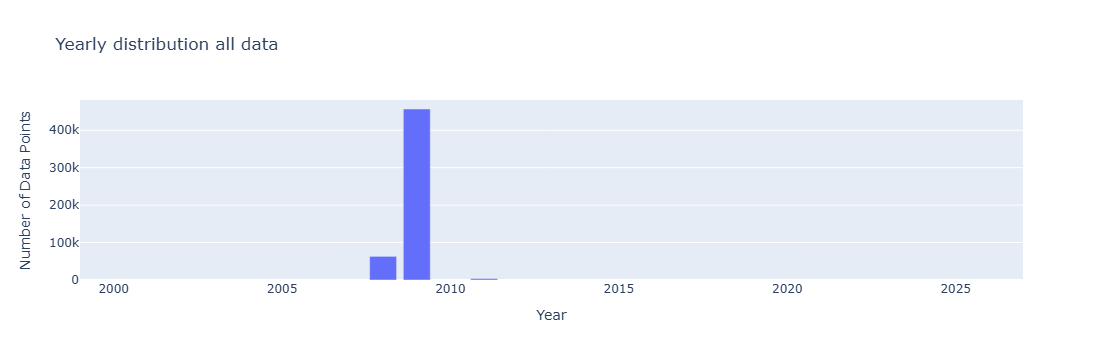

In [3]:
year_test=seabass.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

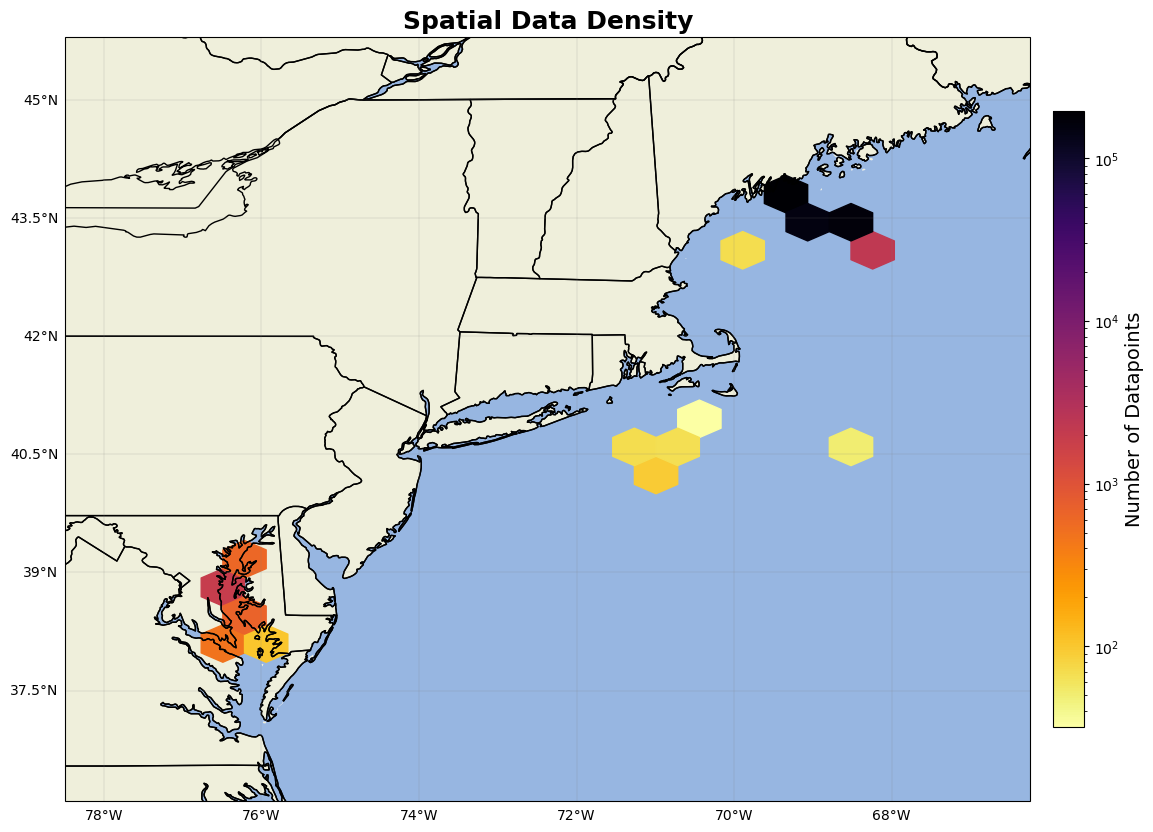

In [5]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=15, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()